# Generate example platemap figure to represent the plate

## Import libraries

In [1]:
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(platetools))


Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘platetools’ was built under R version 4.2.3”


## Set paths

In [2]:
# directory for fig to be outputted
output_dir <- file.path("./platemap_fig")

# Create the output directory if it doesn't exist
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

# path to platemap file
platemap_file <- file.path("./platemaps", "platemap_validation.csv")

# Directory for example platemap figures
output_fig <- file.path(output_dir, "example_platemap.png")


## Load in platemap file

In [3]:
platemap_df <- readr::read_csv(
    platemap_file,
    col_types = readr::cols(.default = "c")
)


print(dim(platemap_df))
head(platemap_df)


[1] 60  7


well_row,well_column,well_position,heart_number,cell_type,heart_failure_type,treatment
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
B,2,B02,7,nonfailing,nonfailing,DMSO
B,3,B03,25,failing,dilated_cardiomyopathy,J0337
B,4,B04,25,failing,dilated_cardiomyopathy,J0899
B,5,B05,7,nonfailing,nonfailing,DMSO
B,6,B06,25,failing,dilated_cardiomyopathy,J0528
B,7,B07,25,failing,dilated_cardiomyopathy,J0375


## Create example platemaps and save figures

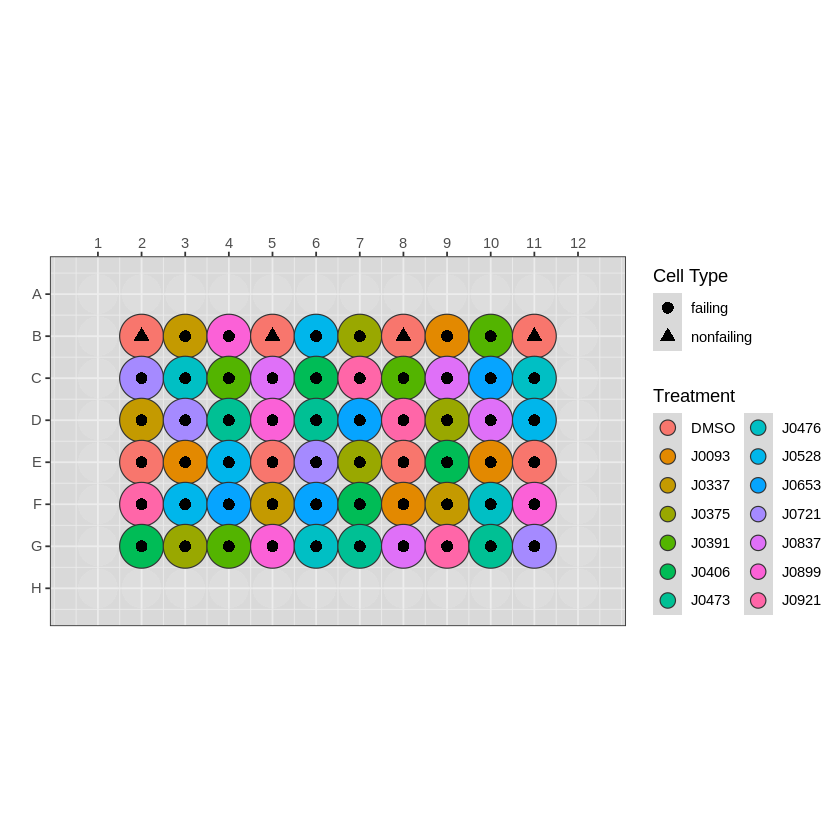

In [4]:
platemap_gg <-
    platetools::raw_map(
        data = platemap_df$treatment, # nolint
        well = platemap_df$well_position,
        plate = 96,
        size = 12
    ) +
    ggplot2::geom_point(aes(shape = platemap_df$cell_type), size = 3) +
    ggplot2::scale_shape_discrete(
        name = "Cell Type",
        guide = ggplot2::guide_legend(override.aes = list(size = 3))
    ) +
    ggplot2::scale_fill_discrete(
        name = "Treatment",
        guide = ggplot2::guide_legend(ncol = 2, override.aes = list(size = 4))
    ) +
    ggplot2::theme(
        panel.background = ggplot2::element_rect(fill = "grey85", color = NA),
        plot.background = ggplot2::element_rect(fill = "white", color = NA)
    )

ggsave(
    output_fig,
    platemap_gg,
    dpi = 500,
    height = 4.5,
    width = 9
)

platemap_gg
